# Results

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from src.models import rmse, rmse_ci

%config InlineBackend.figure_format = 'retina'

In [17]:
sys.path.append("..")

# import forecast data
fc_ipi = pd.read_csv("../data/processed/fc_ipi.csv", index_col=0, parse_dates=True)
fc_cpi = pd.read_csv("../data/processed/fc_cpi.csv", index_col=0, parse_dates=True)

#import actual data
data = pd.read_csv("../data/processed/fredmd_raw_cleaned.csv", index_col=0, parse_dates=True)

T1 = len(data)
T = T1 - len(fc_ipi)
true_ipi = data['INDPRO'][T:]
true_log_cpi = np.log(data['PCEPI'][T:])


## RMSE computation

In [20]:
rmse_ipi = {m: rmse(fc_ipi[m], true_ipi) for m in fc_ipi.columns}
rmse_cpi = {m: rmse(fc_cpi[m], true_log_cpi) for m in fc_cpi.columns}

ci_ipi = rmse_ci(fc_ipi, true_ipi)
ci_cpi = rmse_ci(fc_cpi, true_log_cpi)

print("RMSE with 95% CI for IPI:")
print(ci_ipi)
print("\nRMSE with 95% CI for log(PCEPI):")
print(ci_cpi)

ci_ipi.to_latex("../report/figures/forecast_rmse_ipi_ci.tex", float_format="%.5f")
ci_cpi.to_latex("../report/figures/forecast_rmse_cpi_ci.tex", float_format="%.5f")

RMSE with 95% CI for IPI:
           RMSE     lower     upper
ARp    0.291220  0.288011  0.294430
AR1    0.298414  0.295651  0.301177
Ridge  0.329952  0.326408  0.333495
PCR1   0.336774  0.332067  0.341480
Lasso  0.339615  0.336676  0.342553
PCR6   0.365381  0.362100  0.368662
OLS    0.471460  0.464110  0.478811
RW     0.723668  0.713078  0.734257

RMSE with 95% CI for log(PCEPI):
           RMSE     lower     upper
ARp    0.002450  0.002427  0.002474
AR1    0.002742  0.002716  0.002767
PCR6   0.002866  0.002838  0.002893
Lasso  0.002905  0.002879  0.002930
PCR1   0.002916  0.002889  0.002943
Ridge  0.002944  0.002918  0.002971
OLS    0.003346  0.003317  0.003375
RW     0.004207  0.004167  0.004247


Forecasts for IP are more volatile than for PCEPI. AR models outperform all large-predictor methods for IPI, with AR(p) achieving the lowest RMSE. Shrinkage and PCR models improve over the random walk but do not beat simple autoregressions at the one-month horizon. For PCEPI the ranking is compressed and differences are small, though ARp remains the best performer. OLS is the worst regularized model in both cases, confirming the curse of dimensionality without penalization.

In [21]:
# Save CI tables as LaTeX
ci_ipi.to_latex("../report/figures/forecast_rmse_ci_ipi.tex", float_format="%.5f")
ci_cpi.to_latex("../report/figures/forecast_rmse_ci_cpi.tex", float_format="%.5f")
print("RMSE CI tables saved.")

RMSE CI tables saved.


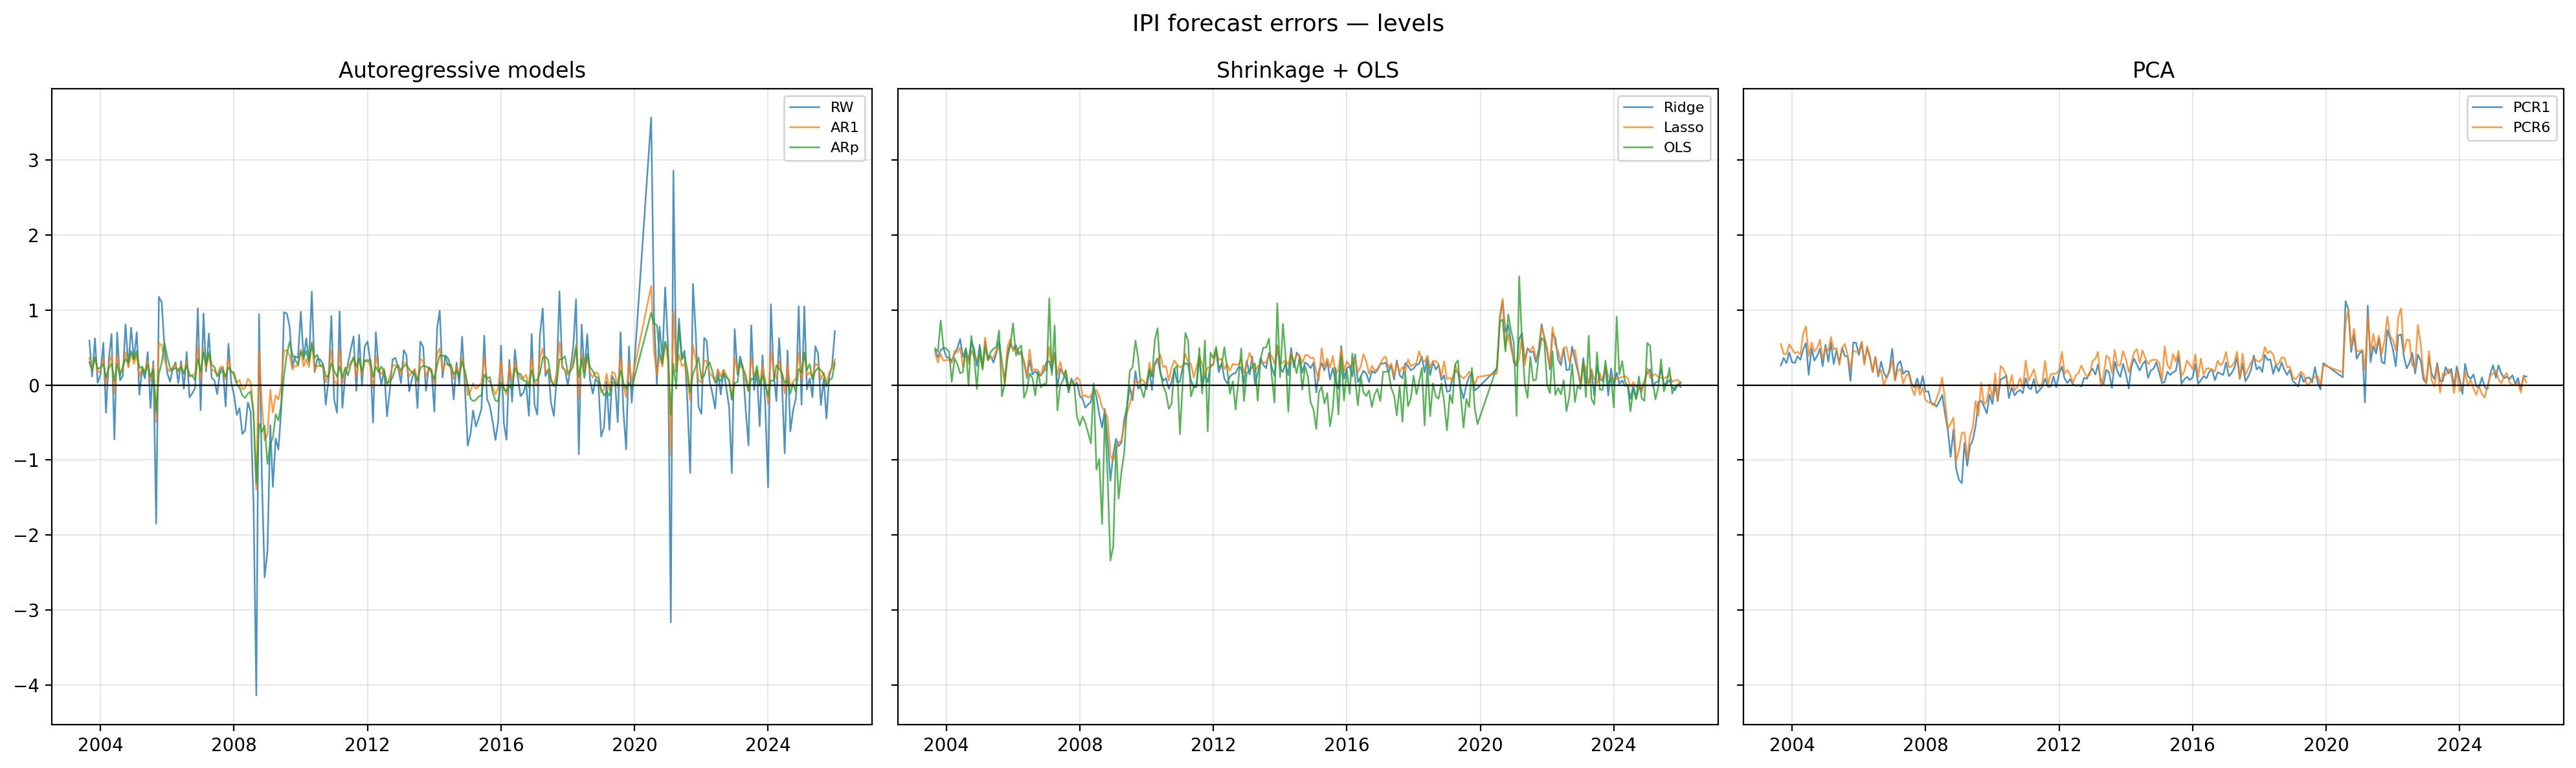

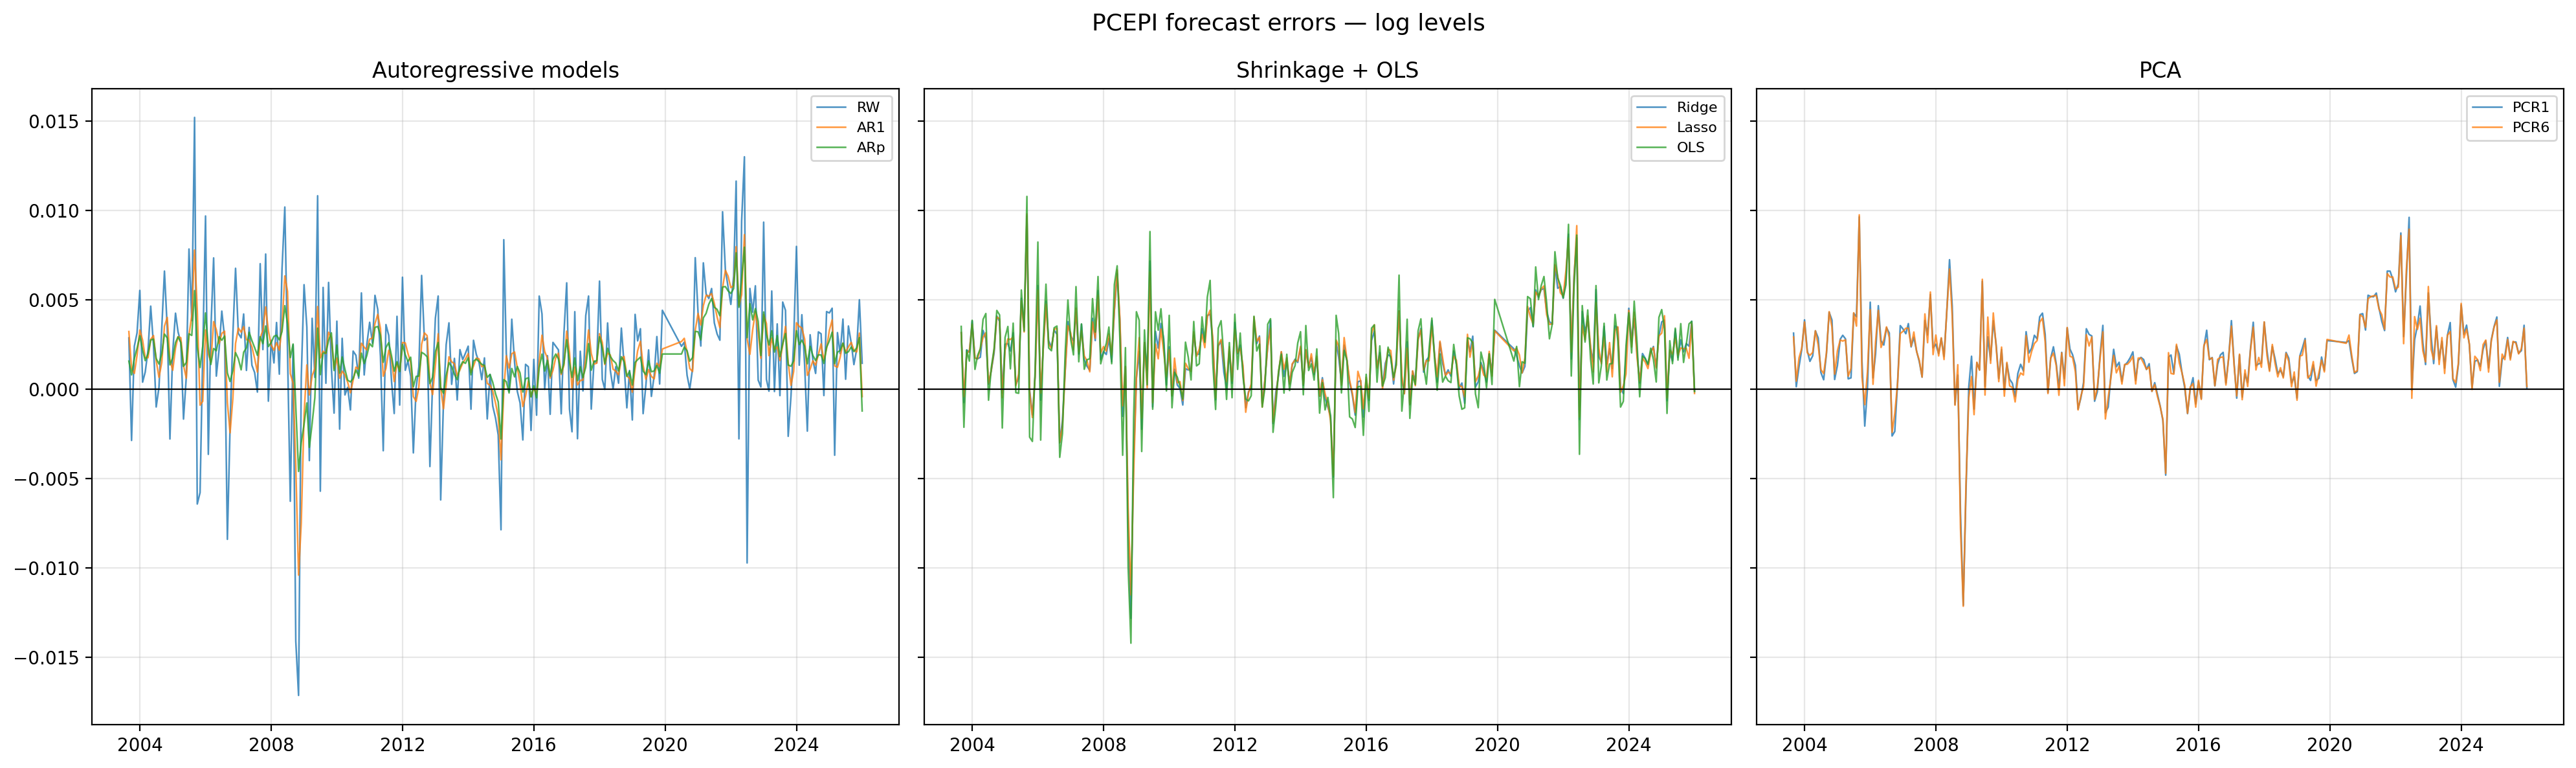

In [19]:
dates = pd.DatetimeIndex(fc_cpi.index)

groups = {
    "Autoregressive models": ["RW", "AR1","ARp"],
    "Shrinkage + OLS": ["Ridge", "Lasso","OLS"],
    "PCA": ["PCR1", "PCR6"]
    }

# ── IPI errors
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
fig.suptitle("IPI forecast errors — levels", fontsize=13)

for ax, (title, group) in zip(axes, groups.items()):
    for m in group:
        err = fc_ipi[m] - true_ipi
        ax.plot(dates, err, linewidth=0.9, alpha=0.8, label=m)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../report/figures/ipi_forecast_errors.png", dpi=300)
plt.show()

# ── PCEPI errors
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
fig.suptitle("PCEPI forecast errors — log levels", fontsize=13)

for ax, (title, group) in zip(axes, groups.items()):
    for m in group:
        err = fc_cpi[m] - true_log_cpi
        ax.plot(dates, err, linewidth=0.9, alpha=0.8, label=m)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../report/figures/cpi_forecast_errors.png", dpi=300)
plt.show()
